In [15]:
%load_ext autoreload
%autoreload 2

# for src folder access
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import os
from matplotlib import pyplot as plt

from src.config import Config, DEFAULT_DATA_ROOT, TRIMMED_DATA_ROOT, default_session_to_activity
from src.preprocessing.clap_sync import accel_magnitude
from src.preprocessing.io_ax6 import find_session_file, load_ax6_csv, resample_to_fs

DEFAULT_DATA_ROOT

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


WindowsPath('C:/Users/TUFA17/OneDrive/Desktop/HAR_Projekt_LSTM_added_class/ax6_cnn_project/data/raw')

### Load data

In [17]:
import pandas as pd

for s in range(12, 28):
    left = find_session_file(DEFAULT_DATA_ROOT, Config.left_id, s)
    right = find_session_file(DEFAULT_DATA_ROOT, Config.right_id, s)

    dfL = pd.read_csv(left, header=None)
    dfR = pd.read_csv(right, header=None)

    print(s, "L cols:", dfL.shape[1], "R cols:", dfR.shape[1], "paths:", left.split("\\")[-1], right.split("\\")[-1])


12 L cols: 7 R cols: 7 paths: 6033722_0000000012.csv 6032357_0000000012.csv
13 L cols: 7 R cols: 7 paths: 6033722_0000000013.csv 6032357_0000000013.csv
14 L cols: 7 R cols: 7 paths: 6033722_0000000014.csv 6032357_0000000014.csv
15 L cols: 7 R cols: 7 paths: 6033722_0000000015.csv 6032357_0000000015.csv
16 L cols: 7 R cols: 7 paths: 6033722_0000000016.csv 6032357_0000000016.csv
17 L cols: 7 R cols: 7 paths: 6033722_0000000017.csv 6032357_0000000017.csv
18 L cols: 7 R cols: 7 paths: 6033722_0000000018.csv 6032357_0000000018.csv
19 L cols: 7 R cols: 7 paths: 6033722_0000000019.csv 6032357_0000000019.csv
20 L cols: 7 R cols: 7 paths: 6033722_0000000020.csv 6032357_0000000020.csv
21 L cols: 7 R cols: 7 paths: 6033722_0000000021.csv 6032357_0000000021.csv
22 L cols: 7 R cols: 7 paths: 6033722_0000000022.csv 6032357_0000000022.csv
23 L cols: 7 R cols: 7 paths: 6033722_0000000023.csv 6032357_0000000023.csv
24 L cols: 7 R cols: 7 paths: 6033722_0000000024.csv 6032357_0000000024.csv
25 L cols: 7

In [18]:
data_paths = [
    [
        find_session_file(DEFAULT_DATA_ROOT, Config.left_id, s), 
        find_session_file(DEFAULT_DATA_ROOT, Config.right_id, s)
    ] for s in range(12, 28)
]

dfs = [
    [
        resample_to_fs(load_ax6_csv(left), Config.fs), 
        resample_to_fs(load_ax6_csv(right), Config.fs)
    ] for left, right in data_paths]

dfs[0][0]

,t,ax,ay,az,gx,gy,gz
0,0.00,0.457275,-0.284668,-1.275146,80.673210,73.585510,74.569702
1,0.01,0.274414,-0.134521,-1.105713,81.993095,74.516296,46.974178
2,0.02,0.167236,-0.146973,-0.964355,66.703796,65.368652,41.381832
3,0.03,0.145996,-0.179443,-0.909668,57.228085,73.089600,25.428770
4,0.04,-0.001221,-0.260254,-0.736328,59.989925,61.523434,12.123107
...,...,...,...,...,...,...,...
22715,227.15,-0.206543,1.079102,-0.125244,-55.984493,-6.027221,35.491943
22716,227.16,-0.222656,1.191895,-0.049072,-64.254761,-2.662658,41.618343
22717,227.17,-0.220947,1.266357,0.046631,-72.799683,0.091553,43.312069
22718,227.18,-0.207520,1.220459,0.049316,-79.162598,-1.251221,38.772583


### Calculate acceloration magnitude

In [19]:
for dfL, dfR in dfs:
    dfL["acc_mag"] = accel_magnitude(dfL)
    dfR["acc_mag"] = accel_magnitude(dfR)

In [20]:
# interactive plot
%matplotlib widget

from typing import Tuple
import pandas as pd


class InteractiveCutter:
    def __init__(self, dfL, dfR, exercise_id, figsize=(15, 3)):
        """Interactive plot using pyplot for manually removing excess data 

        Args:
            dfL (pandas.DataFrame): DataFrame from left sensor
            dfR (pandas.DataFrame): DataFrame from right sensor
            exercise_id (str): Plot label (just decorative)
            figsize (tuple, optional): (width, height). Defaults to (15, 3).
        """
        self.active_line = None  # currently picked lines
        self.dfL = dfL
        self.dfR = dfR
        
        self.fig, (self.ax1, self.ax2) = plt.subplots(2, 1, figsize=figsize)
        
        # plot
        self.dfL["acc_mag"].plot(ax=self.ax1, label="Left Sensor")
        self.dfR["acc_mag"].plot(ax=self.ax2, label="Right Sensor")
        
        # calc initial vlines indices
        idx_min = self.dfL.index.min()
        idx_max = self.dfL.index.max()
        width = (idx_max - idx_min) * 0.2
        p1, p2 = idx_min + 100, idx_min + 100 + width  # same for dfL and dfR
        
        self.lines = [
            self.ax1.axvline(p1, color='red', linestyle='--', lw=3, picker=5),
            self.ax1.axvline(p2, color='red', linestyle='--', lw=3, picker=5),
            self.ax2.axvline(p1, color='red', linestyle='--', lw=3, picker=5),
            self.ax2.axvline(p2, color='red', linestyle='--', lw=3, picker=5)
        ]
        
        # link callback methods
        self.fig.canvas.mpl_connect('pick_event', self._on_pick)
        self.fig.canvas.mpl_connect('motion_notify_event', self._on_motion)
        self.fig.canvas.mpl_connect('button_release_event', self._on_release)
        
        self.ax1.title.set_text(str(exercise_id))
        plt.tight_layout()
        plt.show()

    def _on_pick(self, event):
        if event.artist in self.lines:
            self.active_line = event.artist

    def _on_release(self, event):
        self.active_line = None

    def _on_motion(self, event):
        if self.active_line and event.xdata is not None:
            # get current positions
            l1, r1 = self.lines[0].get_xdata()[0], self.lines[1].get_xdata()[0]
            l2, r2 = self.lines[2].get_xdata()[0], self.lines[3].get_xdata()[0]
            
            # moved lines in first plot
            if self.active_line in self.lines[:2]:
                self.active_line.set_xdata([event.xdata, event.xdata])
                
                # calc distance of lines in first plot to ...
                new_width = abs(self.lines[1].get_xdata()[0] - self.lines[0].get_xdata()[0])
                
                # ... force same width in second plot
                self.lines[3].set_xdata([l2 + new_width, l2 + new_width])
            
            # moved lines in second plot
            elif self.active_line in self.lines[2:]:
                width_top = abs(r1 - l1)
                if self.active_line == self.lines[2]:   # left line picked -> move right line to keep same width
                    self.lines[2].set_xdata([event.xdata, event.xdata])
                    self.lines[3].set_xdata([event.xdata + width_top, event.xdata + width_top])
                else:                                   # right line picked -> move left line too
                    self.lines[3].set_xdata([event.xdata, event.xdata])
                    self.lines[2].set_xdata([event.xdata - width_top, event.xdata - width_top])
            
            self.fig.canvas.draw_idle()

    def get_data(self) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """Extracts data between set lines and create new DataFrames

        Returns:
            Tuple[pd.DataFrame, pd.DataFrame]: dfL_cut, dfR_cut
        """
        lim_L = sorted([self.lines[0].get_xdata()[0], self.lines[1].get_xdata()[0]])
        lim_R = sorted([self.lines[2].get_xdata()[0], self.lines[3].get_xdata()[0]])
        
        df_cut_L = self.dfL.loc[(self.dfL.index >= lim_L[0]) & (self.dfL.index <= lim_L[1])].copy()
        df_cut_R = self.dfR.loc[(self.dfR.index >= lim_R[0]) & (self.dfR.index <= lim_R[1])].copy()
        
        return df_cut_L, df_cut_R

### Trim manually

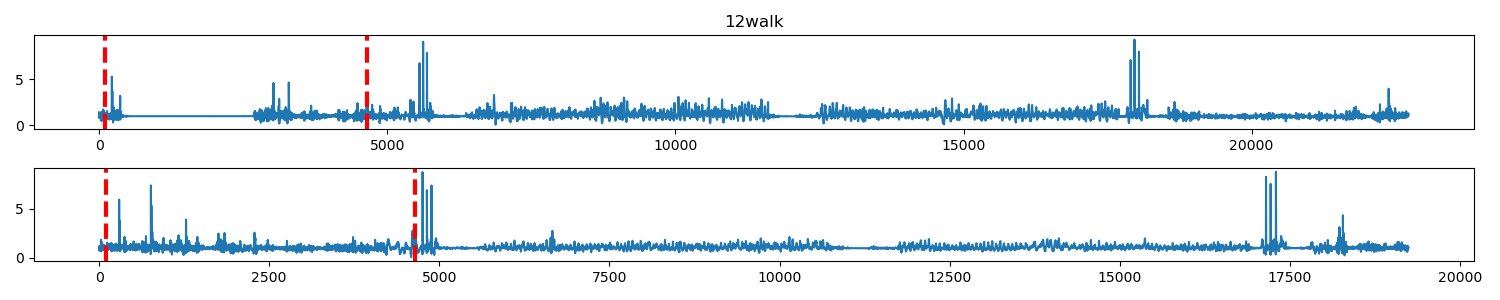

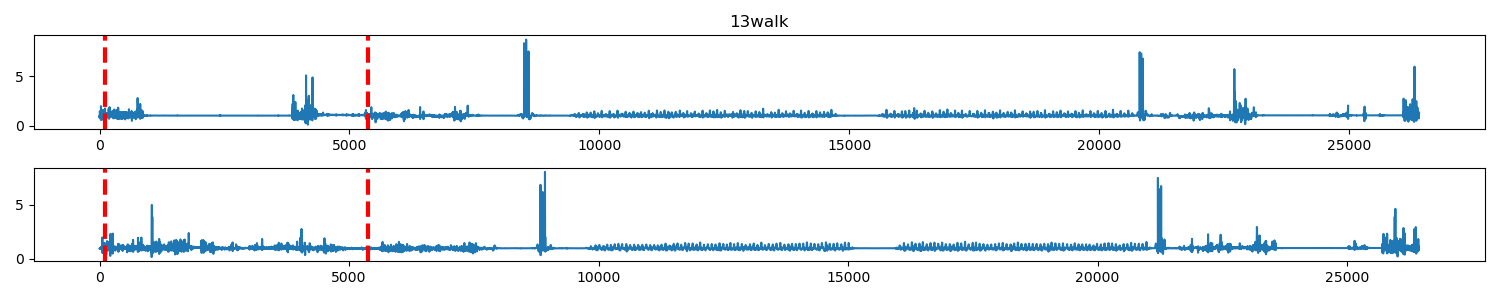

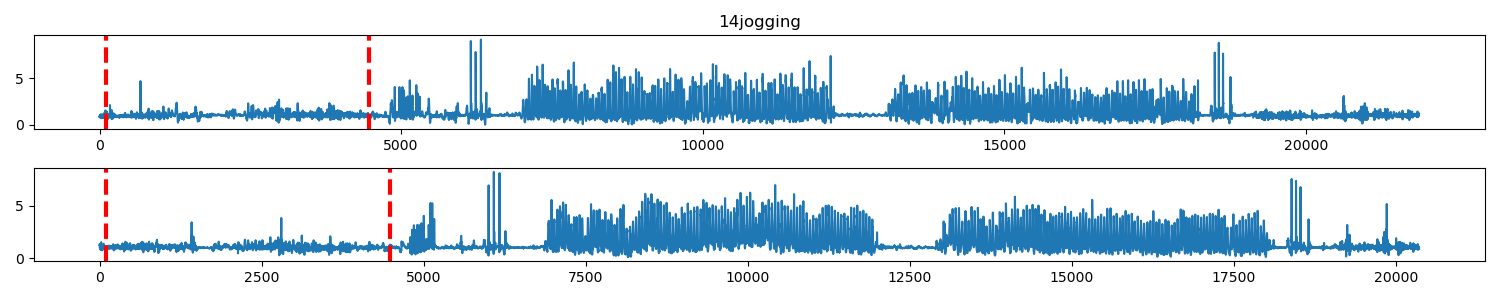

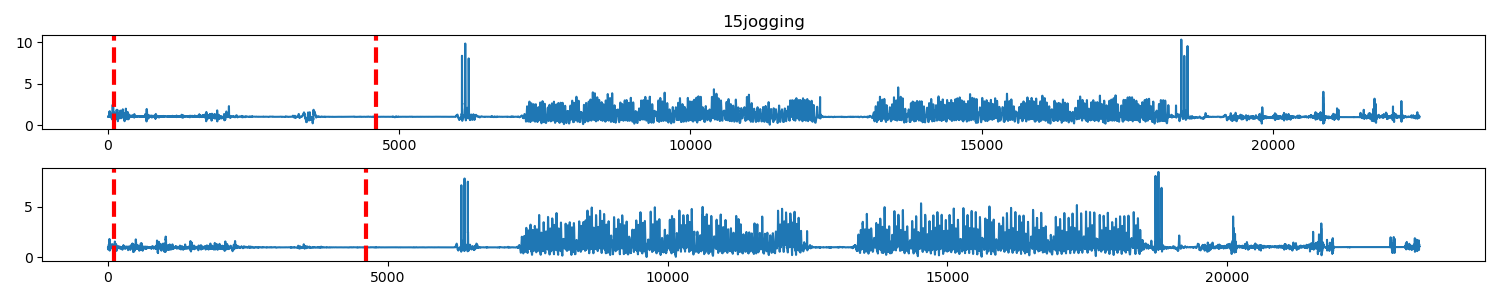

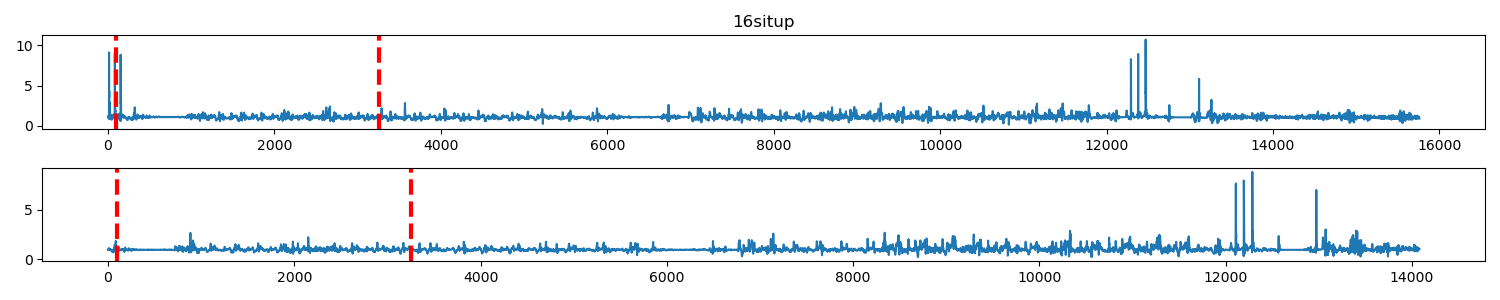

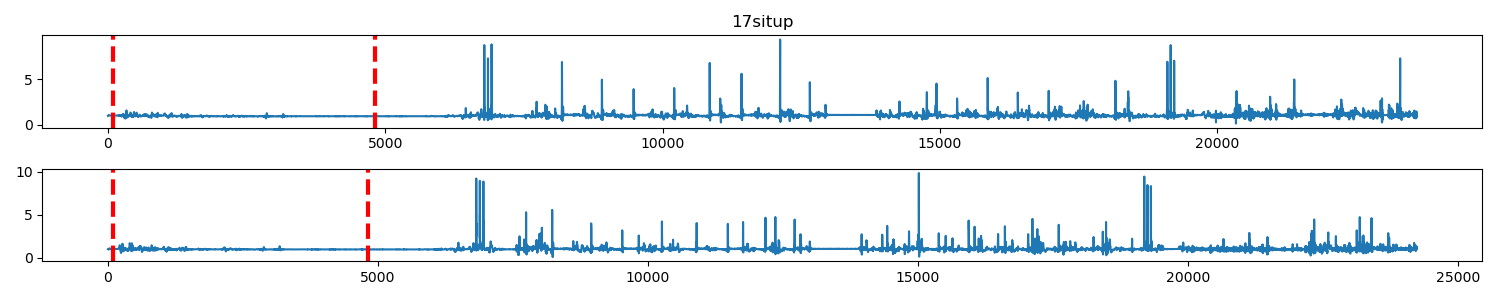

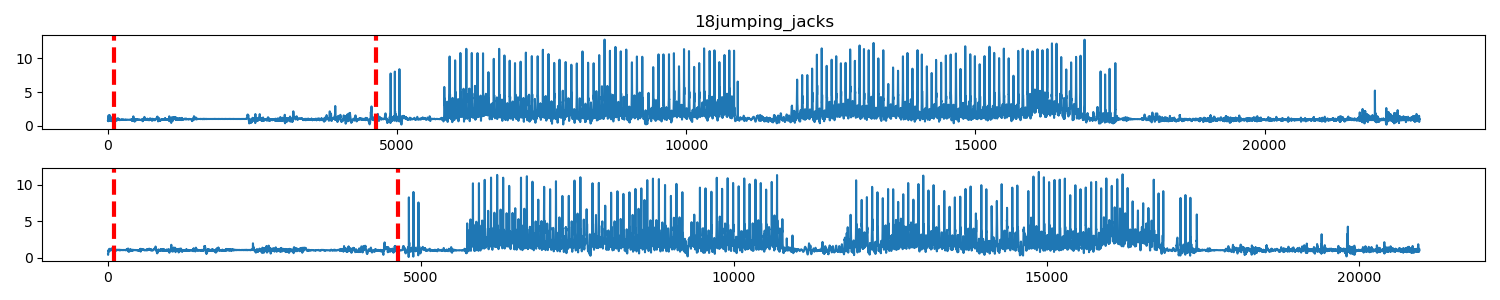

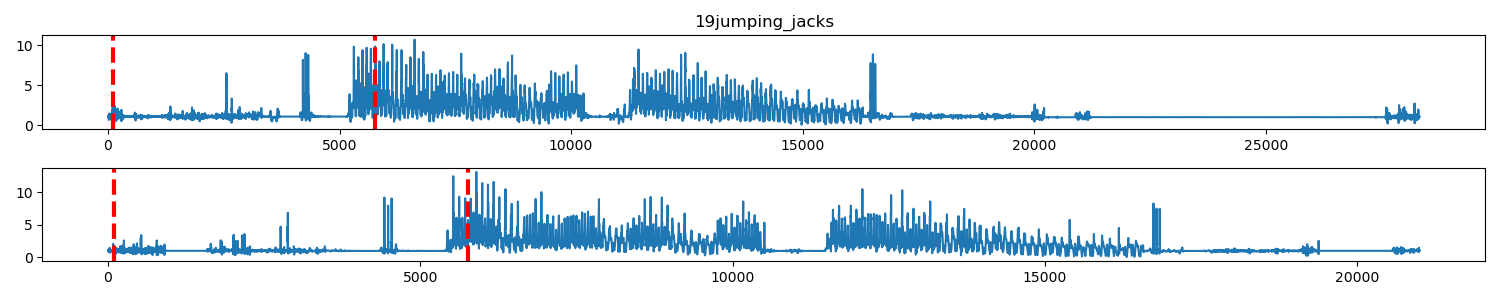

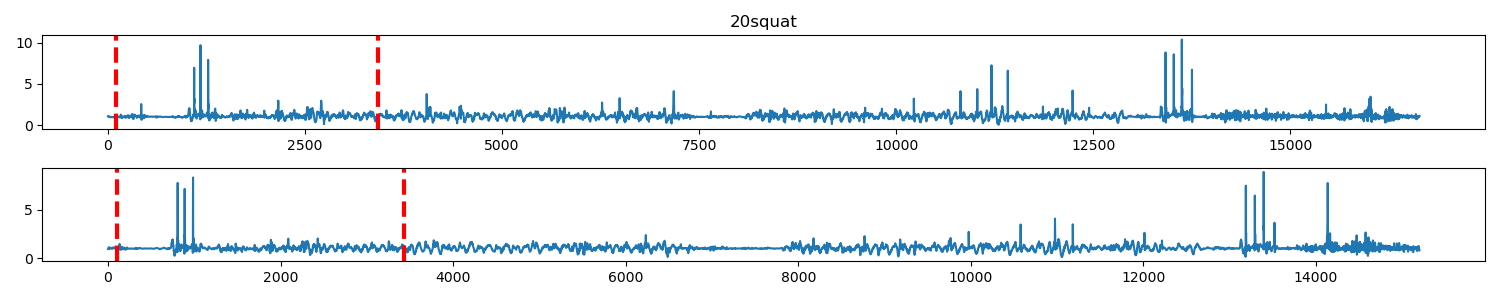

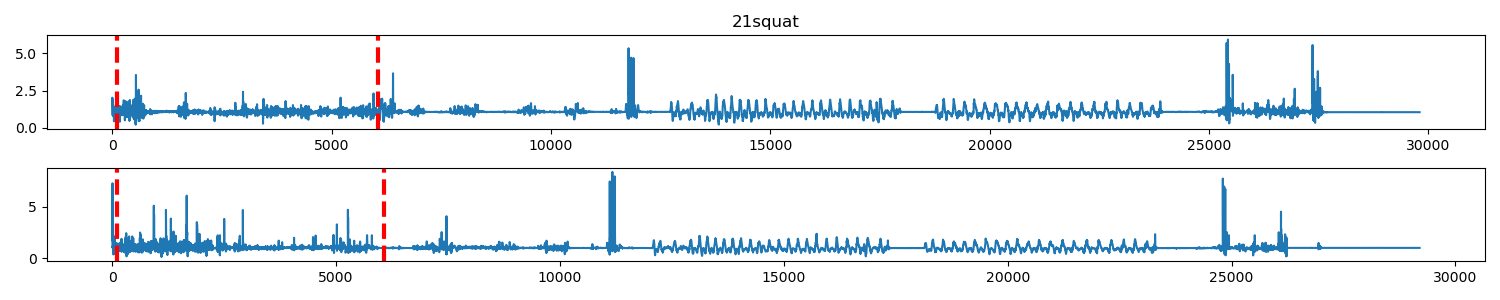

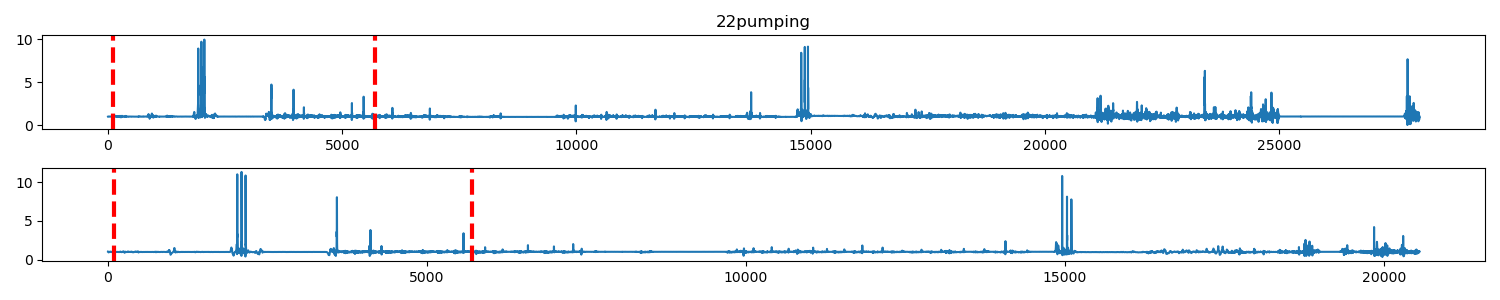

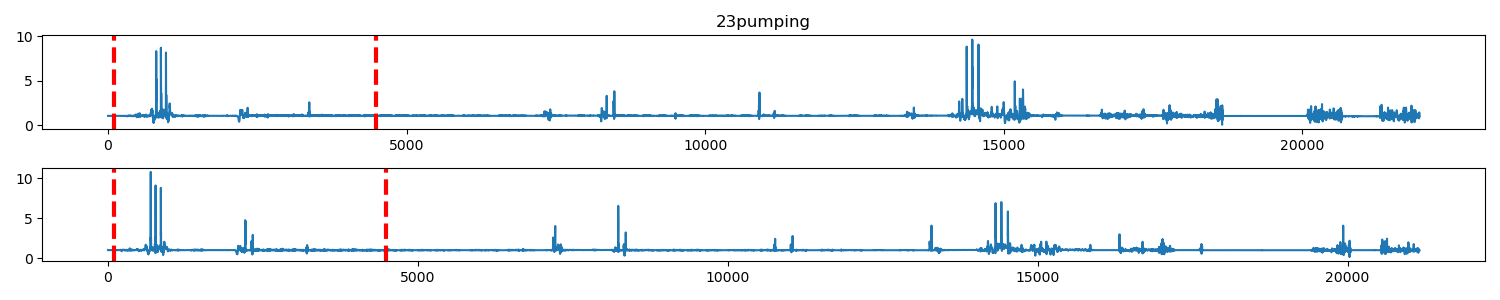

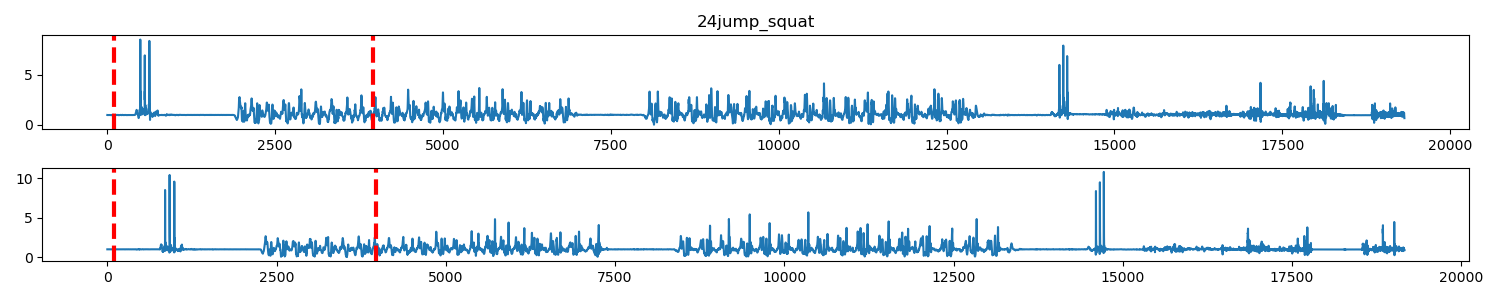

C:\Users\TUFA17\AppData\Local\Temp\ipykernel_24016\2926842687.py:22: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self.fig, (self.ax1, self.ax2) = plt.subplots(2, 1, figsize=figsize)


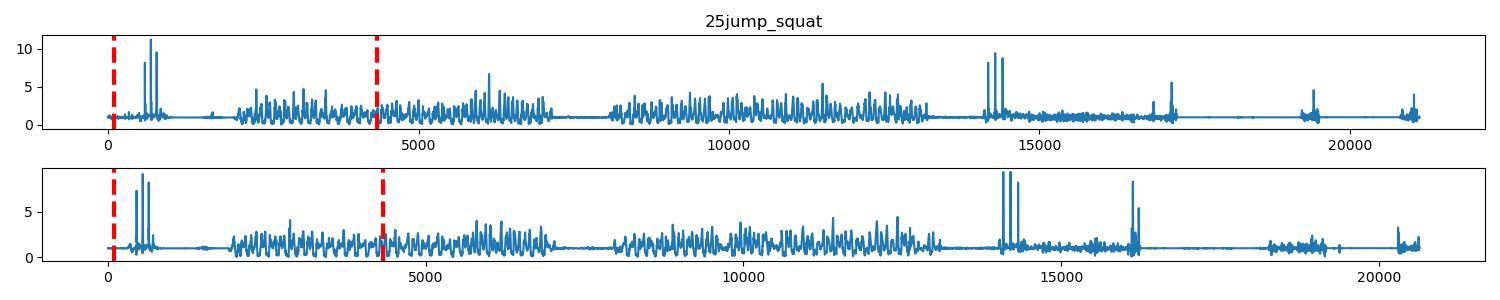

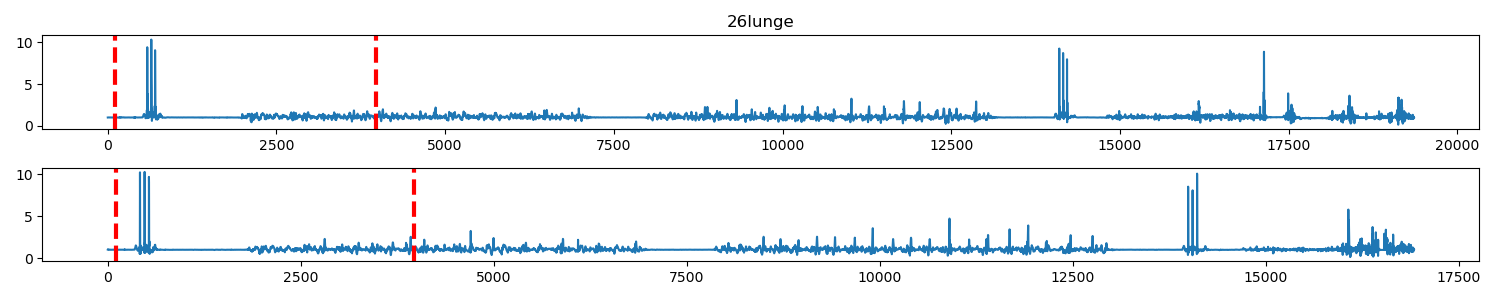

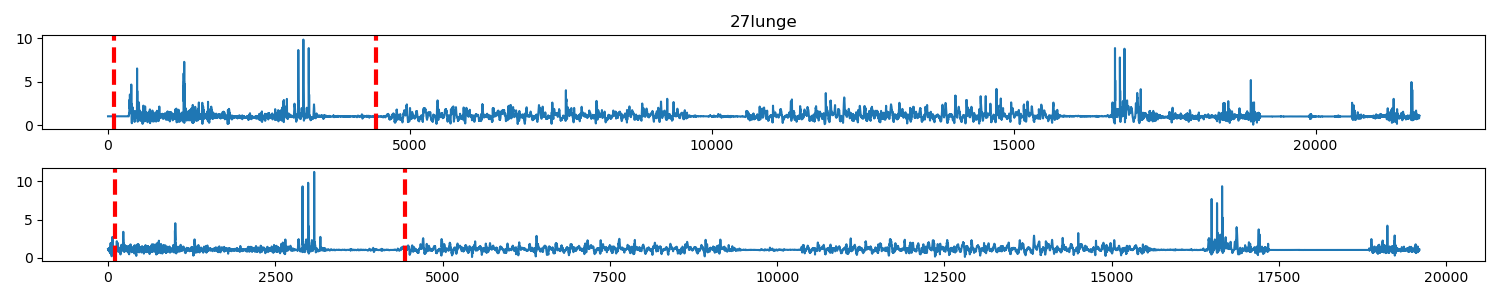

In [21]:
cutters = [InteractiveCutter(dfL, dfR, str(id)+default_session_to_activity()[id]) for id, (dfL, dfR) in enumerate(dfs, start=12)]

### Result example (interactive plots wont be saved when juypter server restarts)

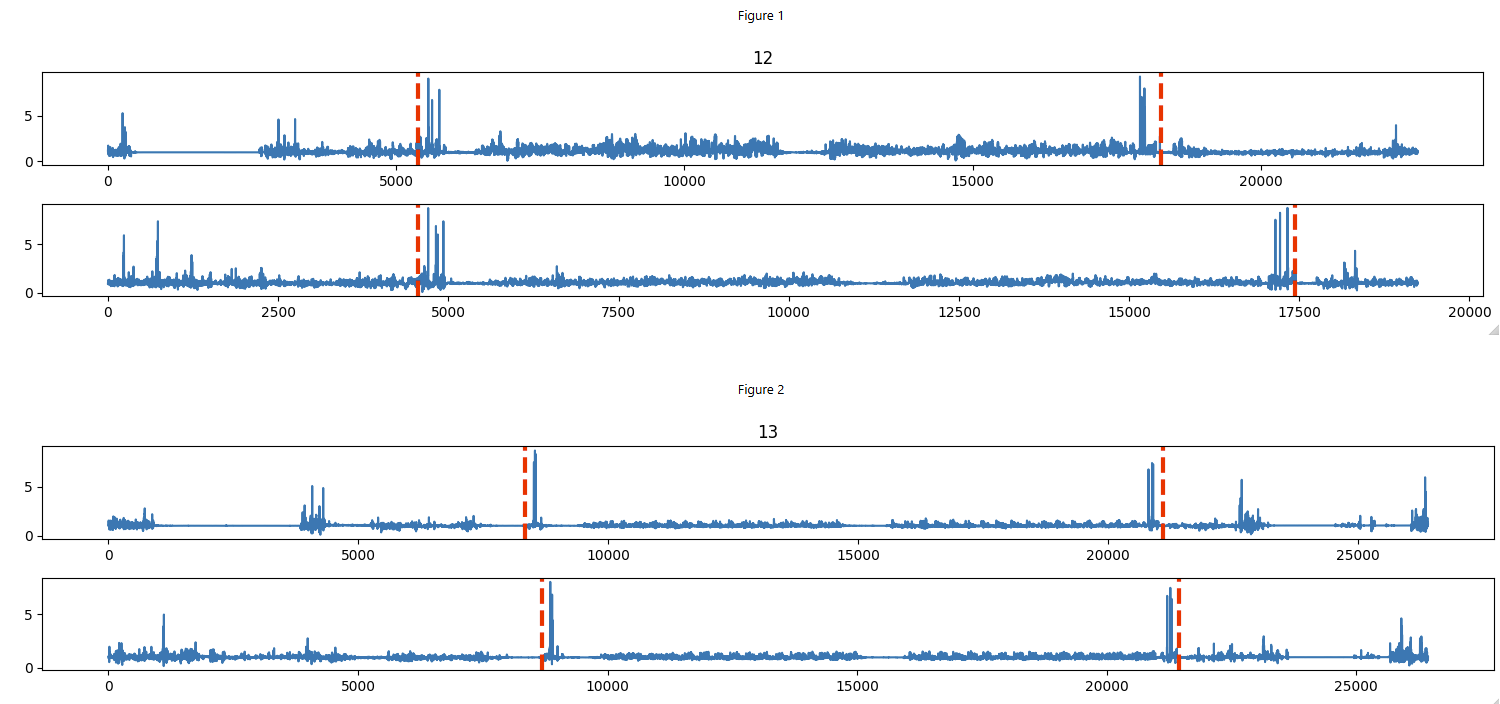

In [22]:
from IPython.display import Image
Image(filename="example_trim.png")

### Show first 6 seconds (later used for synchronisation)

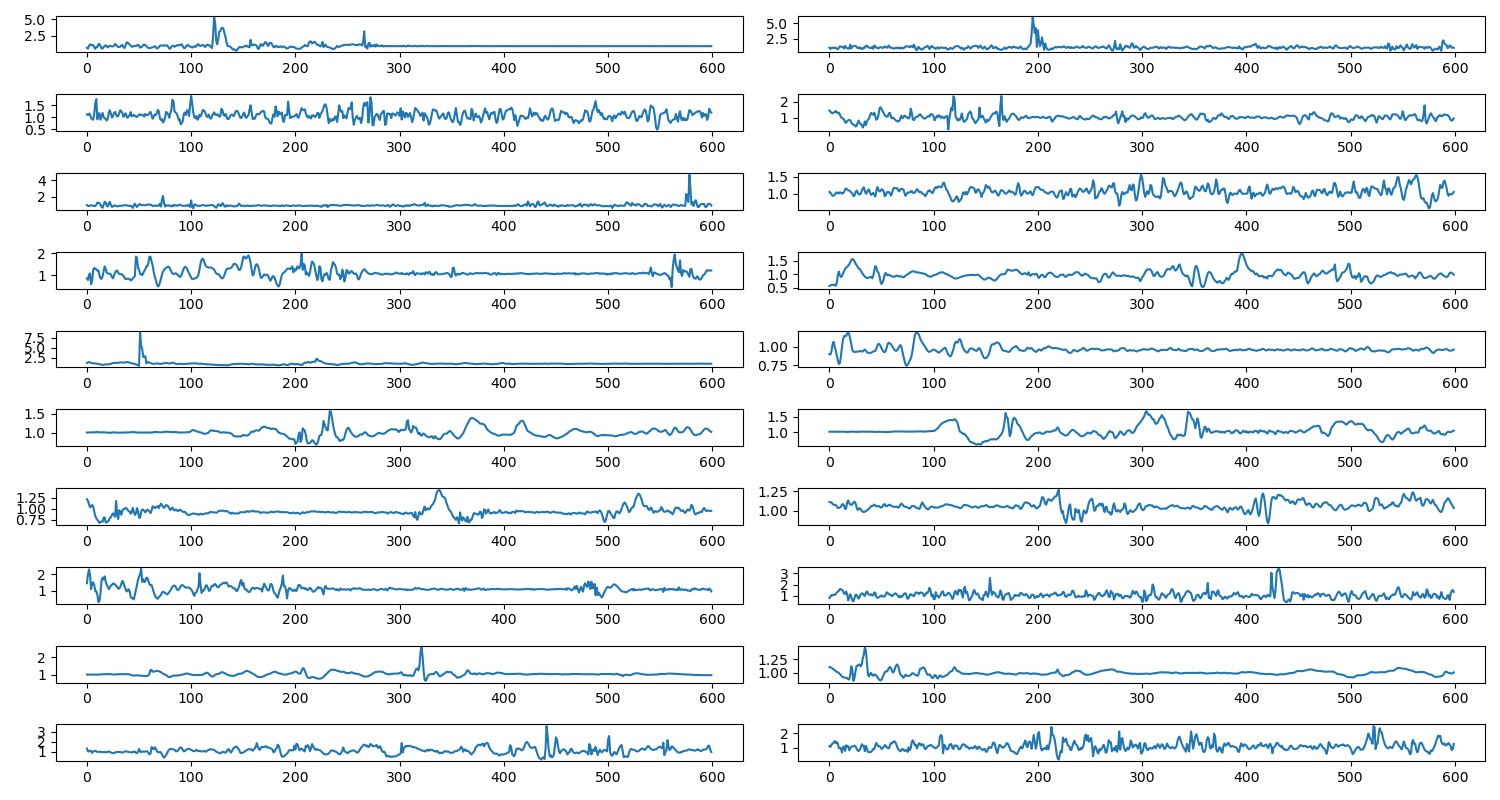

In [23]:
trimmed_dfs = [c.get_data() for c in cutters]

fig, ax = plt.subplots(10, 2, figsize=(15, 8))
for (ax1, ax2), (dfL, dfR) in zip(ax, trimmed_dfs):
    ax1.plot(accel_magnitude(dfL)[:600])
    ax2.plot(accel_magnitude(dfR)[:600])
plt.tight_layout()

### Save the files

In [25]:
if not os.path.exists(TRIMMED_DATA_ROOT):
    os.mkdir(TRIMMED_DATA_ROOT)
    
for (dfL, dfR), id in zip(trimmed_dfs, range(12, 28)):
    _path = os.path.join(TRIMMED_DATA_ROOT, str(id))
    if _path + "left.csv" not in os.listdir(TRIMMED_DATA_ROOT):
        dfL.to_csv(_path + "left.csv", index=False)
        dfR.to_csv(_path + "right.csv", index=False)